In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Dataset
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2025-10-05 15:08:52--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.07s   

2025-10-05 15:08:53 (11.5 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [4]:
# Load dataset
df = pd.read_csv('car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [29]:
# Discard cols
cols_to_keep = [
    "engine_displacement", "horsepower", "vehicle_weight", "model_year", "fuel_efficiency_mpg"]
df = df[cols_to_keep]

Text(0.5, 1.0, 'Distribution of fuel_efficiency_mpg')

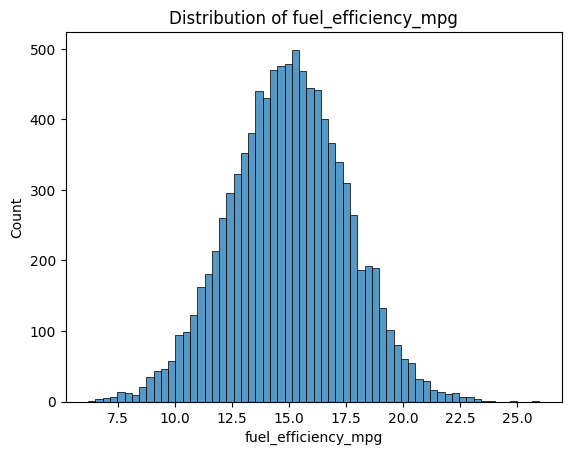

In [30]:
# Plot target variable
sns.histplot(df['fuel_efficiency_mpg'])
plt.xlabel('fuel_efficiency_mpg')
plt.ylabel('Count')
plt.title('Distribution of fuel_efficiency_mpg')

In [31]:
# Null values
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [32]:
# Median of horsepower
df['horsepower'].median()

np.float64(149.0)

In [40]:
# Train, validation test split

# Number of samples
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Shuffle indices
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

# Create splits
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

df_train.shape, df_val.shape, df_test.shape

((5824, 5), (1940, 5), (1940, 5))

In [41]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,220,144.0,2535.887591,2009,16.642943
1,160,141.0,2741.170484,2019,16.298377
2,230,155.0,2471.880237,2017,18.591822
3,150,206.0,3748.164469,2015,11.818843
4,300,111.0,2135.716359,2006,19.402209
...,...,...,...,...,...
5819,260,139.0,2606.972984,2009,16.964054
5820,280,132.0,4004.214323,2014,10.059094
5821,210,152.0,2500.175687,2020,17.593237
5822,250,154.0,2254.313245,2002,18.925748


In [42]:
# Train linear regression
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# RMSE
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [43]:
# Prepare dataset
def prepare_X(df, null_value: float=None):
    df = df.copy()
    df = df.drop(columns=['fuel_efficiency_mpg'])
    if null_value is not None:
        df['horsepower'] = df['horsepower'].fillna(null_value)
    return df.values

In [47]:
# Fill null with zeroes
X_train = prepare_X(df_train, null_value=0)
X_val = prepare_X(df_val, null_value=0)

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.5173782638857467)

In [48]:
# Fill nulls with median
median_hp = df_train["horsepower"].median()
X_train = prepare_X(df_train, null_value=median_hp)
X_val = prepare_X(df_val, null_value=median_hp)

w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.46357254794660463)

In [52]:
# Regularized linear regression
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [58]:
# Find best reg paramater
X_train = prepare_X(df_train, null_value=0)
X_val = prepare_X(df_val, null_value=0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    print(f"RMSE for r={r}: {round(rmse(y_val, y_pred), 2)}")

RMSE for r=0: 0.52
RMSE for r=0.01: 0.52
RMSE for r=0.1: 0.52
RMSE for r=1: 0.52
RMSE for r=5: 0.52
RMSE for r=10: 0.52
RMSE for r=100: 0.52


In [59]:
def train_val_test_split(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    return df_train, y_train, df_val, y_val, df_test, y_test

In [60]:
# Train with different splits
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

scores = np.zeros(len(seeds))
for i, seed in enumerate(seeds):
    df_train, y_train, df_val, y_val, df_test, y_test = train_val_test_split(df, seed=seed)
    
    X_train = prepare_X(df_train, null_value=0)
    X_val = prepare_X(df_val, null_value=0)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    scores[i] = rmse(y_val, y_pred)
    print(f"Seed: {seed}, RMSE: {scores[i]}")

Seed: 0, RMSE: 0.5206531296292951
Seed: 1, RMSE: 0.5213388912860217
Seed: 2, RMSE: 0.5228069974785726
Seed: 3, RMSE: 0.5159516741108942
Seed: 4, RMSE: 0.5109129460108117
Seed: 5, RMSE: 0.5283406460133415
Seed: 6, RMSE: 0.5313910658151165
Seed: 7, RMSE: 0.5090670387365963
Seed: 8, RMSE: 0.5147399129426932
Seed: 9, RMSE: 0.5131865908408015


In [61]:
# Standard deviation of scores
round(np.std(scores), 3)

np.float64(0.007)

In [64]:
# Train on whole dataset and test
df_train, y_train, df_val, y_val, df_test, y_test = train_val_test_split(df, seed=9)

X_train = prepare_X(df_train, null_value=0)
X_val = prepare_X(df_val, null_value=0)
X_test = prepare_X(df_test, null_value=0)

X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

w0, w = train_linear_regression_reg(X_full, y_full, r=0.001)
y_pred = w0 + X_test.dot(w)
print(f"Test RMSE: {round(rmse(y_test, y_pred), 3)}")

Test RMSE: 0.516
